In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import joblib
def calculate_vif(df, numeric_features):
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    X_numeric = df[numeric_features].copy()

    vif_table = pd.DataFrame({
        "Feature": X_numeric.columns,
        "VIF": [
            variance_inflation_factor(X_numeric.values, i)
            for i in range(X_numeric.shape[1])
        ]
    })

    return vif_table

In [2]:
# Load dataset
df = pd.read_csv("house_price_prediction_dataset.csv")

In [3]:
# Display basic information
print("Dataset shape:", df.shape)

Dataset shape: (125, 9)


In [4]:
print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
0,1001,144.6,2.0,2.0,15.0,27.40,0.0,Kigali City,104.8
1,1002,101.9,4.0,4.0,15.5,5.97,1.0,Huye,137.0
2,1003,157.1,3.0,2.0,8.9,2.42,1.0,Nyarugenge,171.6
3,1004,254.2,3.0,2.0,15.5,6.68,1.0,Musanze,197.2
4,1005,96.7,3.0,2.0,9.5,12.34,2.0,Gasabo,121.8


In [5]:
print("\nData types:")
print(df.dtypes)



Data types:
House_ID                     int64
Area_m2                    float64
Bedrooms                   float64
Bathrooms                  float64
House_Age_Years            float64
Distance_to_City_km        float64
Parking_Spaces             float64
Neighborhood                   str
House_Price_Million_RWF    float64
dtype: object


In [6]:
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   House_ID                 125 non-null    int64  
 1   Area_m2                  123 non-null    float64
 2   Bedrooms                 124 non-null    float64
 3   Bathrooms                124 non-null    float64
 4   House_Age_Years          124 non-null    float64
 5   Distance_to_City_km      124 non-null    float64
 6   Parking_Spaces           124 non-null    float64
 7   Neighborhood             124 non-null    str    
 8   House_Price_Million_RWF  124 non-null    float64
dtypes: float64(7), int64(1), str(1)
memory usage: 8.9 KB


In [7]:
print("\nSummary statistics:")
display(df.describe(include="all"))


Summary statistics:


,House_ID,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces,Neighborhood,House_Price_Million_RWF
count,125.000000,123.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124,124.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Huye,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25,NaN
mean,1059.000000,134.808943,3.298387,3.016129,9.773387,5.652419,1.185484,NaN,173.254032
std,34.938887,133.300251,1.216284,1.202868,10.435564,8.701097,0.849361,NaN,127.372543
min,1001.000000,26.000000,1.000000,1.000000,0.400000,0.070000,0.000000,NaN,77.700000
25%,1028.000000,82.450000,2.000000,2.000000,3.175000,1.557500,1.000000,NaN,118.525000
50%,1058.000000,107.900000,3.000000,3.000000,6.650000,3.535000,1.000000,NaN,150.650000
75%,1089.000000,141.000000,4.000000,4.000000,12.125000,7.072500,2.000000,NaN,186.675000


In [8]:
#Check missing values
print("Missing values in each column:")
print(df.isna().sum())

Missing values in each column:
House_ID                   0
Area_m2                    2
Bedrooms                   1
Bathrooms                  1
House_Age_Years            1
Distance_to_City_km        1
Parking_Spaces             1
Neighborhood               1
House_Price_Million_RWF    1
dtype: int64


In [9]:
#Check duplicate records
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5


In [10]:
#Remove duplicates:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (120, 9)


In [11]:
#Check impossible values
numeric_columns = [
    "Area_m2",
    "Bedrooms",
    "Bathrooms",
    "House_Age_Years",
    "Distance_to_City_km",
    "Parking_Spaces",
    "House_Price_Million_RWF"
]

for col in numeric_columns:
    print(f"\n{col}")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())


Area_m2
Minimum: 26.0
Maximum: 1200.0

Bedrooms
Minimum: 1.0
Maximum: 6.0

Bathrooms
Minimum: 1.0
Maximum: 5.0

House_Age_Years
Minimum: 0.4
Maximum: 75.0

Distance_to_City_km
Minimum: 0.07
Maximum: 85.0

Parking_Spaces
Minimum: 0.0
Maximum: 3.0

House_Price_Million_RWF
Minimum: 77.7
Maximum: 1200.0


In [12]:
#Check negative values and all columns has number values 
for col in numeric_columns:
    negative_count = (pd.to_numeric(df[col], errors="coerce") < 0).sum()
    print(f"{col}: {negative_count} negative values")

Area_m2: 0 negative values
Bedrooms: 0 negative values
Bathrooms: 0 negative values
House_Age_Years: 0 negative values
Distance_to_City_km: 0 negative values
Parking_Spaces: 0 negative values
House_Price_Million_RWF: 0 negative values


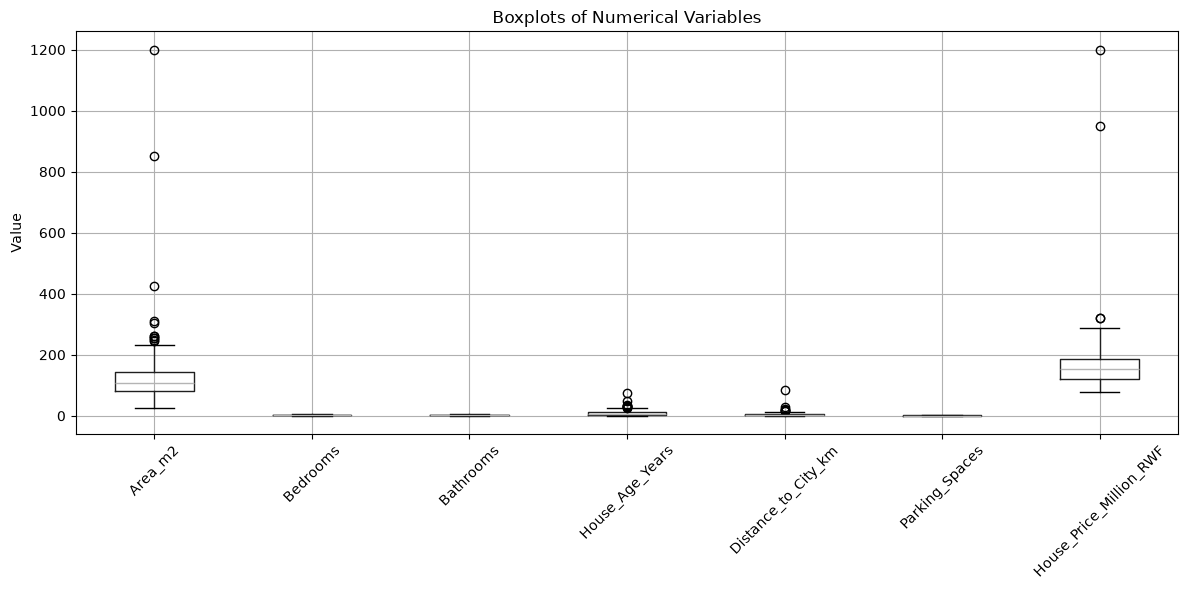

In [13]:
#boxplots visualization
plt.figure(figsize=(12, 6))

df[numeric_columns].boxplot()

plt.title("Boxplots of Numerical Variables")
plt.xticks(rotation=45)
plt.ylabel("Value")
plt.tight_layout()
plt.show()

In [14]:
#Detect outliers using the IQR method
outlier_counts = {}

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_counts[col] = len(outliers)

    print(f"{col}: {len(outliers)} outliers")

print("\nOutlier summary:")
print(pd.Series(outlier_counts))

Area_m2: 11 outliers
Bedrooms: 0 outliers
Bathrooms: 0 outliers
House_Age_Years: 9 outliers
Distance_to_City_km: 7 outliers
Parking_Spaces: 0 outliers
House_Price_Million_RWF: 4 outliers

Outlier summary:
Area_m2                    11
Bedrooms                    0
Bathrooms                   0
House_Age_Years             9
Distance_to_City_km         7
Parking_Spaces              0
House_Price_Million_RWF     4
dtype: int64


We decided to remove the outliers because:
We did not have evidence that the extreme values were genuine special cases.
We couldn't confidently say that the unusual observations represented legitimate luxury houses or unusual properties. Since there was no reliable information to correct them, correction wasn't appropriate.

In [15]:
#Remove outlier rows
df_clean = df.copy()

for col in numeric_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound)
    ]

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (120, 9)
Cleaned shape: (85, 9)


In [16]:
print("Number of rows after cleaning:", len(df_clean))

Number of rows after cleaning: 85


In [17]:
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
House_ID                   0
Area_m2                    0
Bedrooms                   0
Bathrooms                  0
House_Age_Years            0
Distance_to_City_km        0
Parking_Spaces             0
Neighborhood               1
House_Price_Million_RWF    0
dtype: int64


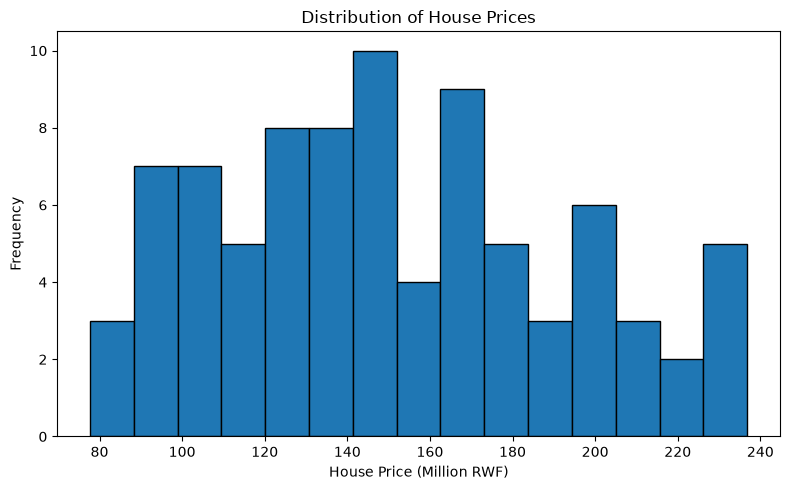

In [18]:
#Visualisation  — Distribution of house prices
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["House_Price_Million_RWF"],
    bins=15,
    edgecolor="black"
)

plt.title("Distribution of House Prices")
plt.xlabel("House Price (Million RWF)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

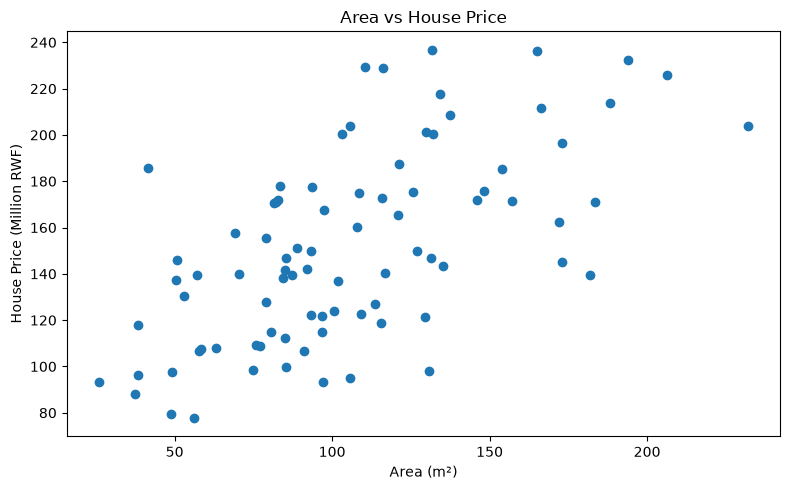

In [19]:
#Visualisation — Area vs Price
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["Area_m2"],
    df_clean["House_Price_Million_RWF"]
)

plt.title("Area vs House Price")
plt.xlabel("Area (m²)")
plt.ylabel("House Price (Million RWF)")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

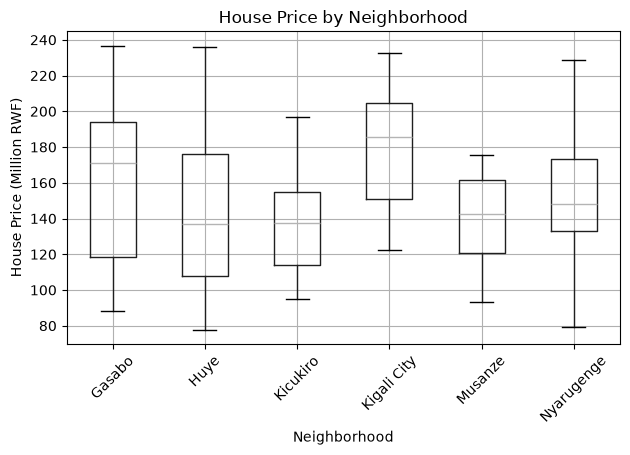

In [20]:
#Visualisation — Price by Neighborhood

plt.figure(figsize=(10, 6))

df_clean.boxplot(
    column="House_Price_Million_RWF",
    by="Neighborhood"
)

plt.title("House Price by Neighborhood")
plt.suptitle("")
plt.xlabel("Neighborhood")
plt.ylabel("House Price (Million RWF)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

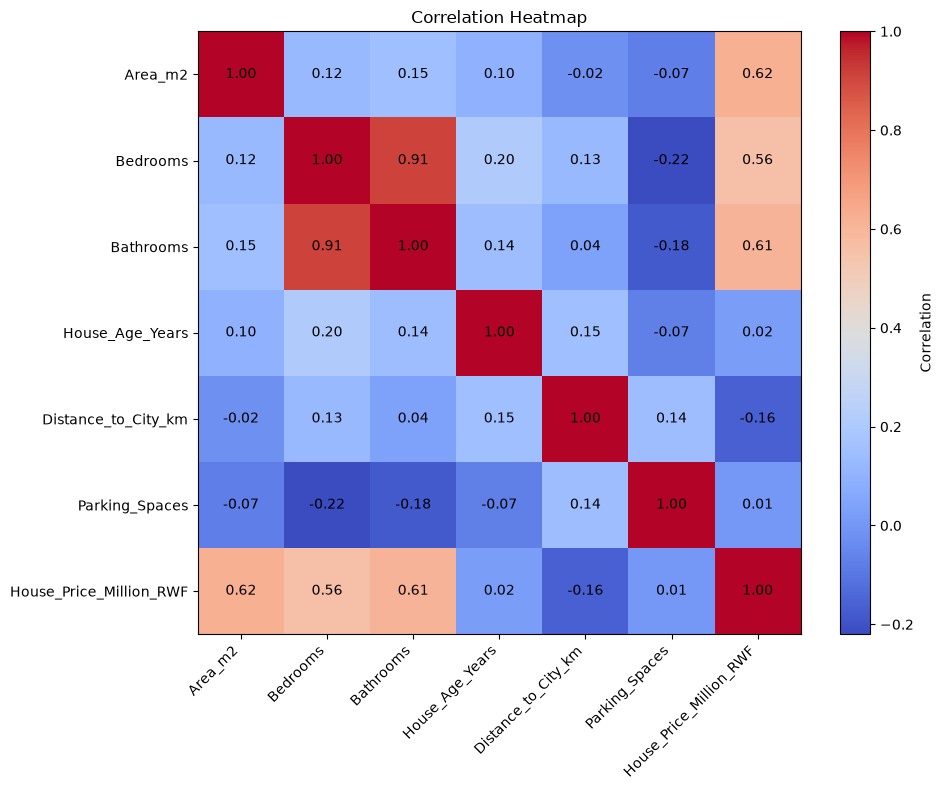

In [21]:
#Visualisation — Correlation heatmap
correlation = df_clean[numeric_columns].corr()

plt.figure(figsize=(10, 8))

plt.imshow(
    correlation,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

# Add correlation values
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [22]:
#Save the cleaned dataset
df_clean.to_csv(
    "house_price_prediction_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [23]:
#Define X and y
target = "House_Price_Million_RWF"

X = df_clean.drop(
    columns=["House_ID", target]
)

y = df_clean[target]

print("X columns:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

X columns:
['Area_m2', 'Bedrooms', 'Bathrooms', 'House_Age_Years', 'Distance_to_City_km', 'Parking_Spaces', 'Neighborhood']

Target:
House_Price_Million_RWF


In [24]:
#Identify numerical and categorical columns
numeric_features = [
    "Area_m2",
    "Bedrooms",
    "Bathrooms",
    "House_Age_Years",
    "Distance_to_City_km",
    "Parking_Spaces"
]

categorical_features = [
    "Neighborhood"
]

In [25]:
#Train/test split
#The assignment specifically requires an 80% training and 20% testing split with random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (68, 7)
Testing data: (17, 7)


In [26]:
# Impute missing numerical values using the median
# Impute missing categorical values using the most frequent value
# One-hot encode Neighborhood
# Drop one category to avoid the dummy-variable trap
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [27]:
#Create the Linear Regression model
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [28]:
#Train the model
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [29]:
#Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Training predictions:")
print(y_train_pred[:5])

print("\nTesting predictions:")
print(y_test_pred[:5])

Training predictions:
[117.2599612  128.24319699 152.19634015 132.76166422  95.24313349]

Testing predictions:
[142.50386444 154.0629832  191.04481007 204.93124535 131.34266429]


In [30]:
#Calculate model performance
def calculate_metrics(y_actual, y_pred, number_of_predictors):
    
    n = len(y_actual)
    
    r2 = r2_score(y_actual, y_pred)
    
    adjusted_r2 = 1 - (
        (1 - r2) * (n - 1) /
        (n - number_of_predictors - 1)
    )
    
    mae = mean_absolute_error(
        y_actual,
        y_pred
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_actual,
            y_pred
        )
    )
    
    return r2, adjusted_r2, mae, rmse

number_of_predictors = X_train.shape[1]

train_metrics = calculate_metrics(
    y_train,
    y_train_pred,
    number_of_predictors
)

test_metrics = calculate_metrics(
    y_test,
    y_test_pred,
    number_of_predictors
)


In [31]:
#Display them:
metrics_table = pd.DataFrame({
    "Metric": [
        "R²",
        "Adjusted R²",
        "MAE",
        "RMSE"
    ],
    
    "Training": train_metrics,
    "Testing": test_metrics
})

display(metrics_table)

,Metric,Training,Testing
0,R²,0.807813,0.589422
1,Adjusted R²,0.785391,0.270083
2,MAE,14.850508,20.093653
3,RMSE,18.322092,24.201140


In [32]:
#Display the intercept
regressor = model.named_steps["regressor"]

print("Intercept:")
print(regressor.intercept_)

Intercept:
35.2090613425419


In [33]:
#Display all coefficients
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = model.named_steps[
    "regressor"
].coef_

#Create a table:
coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_table = coefficient_table.sort_values(
    by="Coefficient",
    ascending=False
)

display(coefficient_table)

,Feature,Coefficient
2,num__Bathrooms,15.015683
8,cat__Neighborhood_Kigali City,13.504679
1,num__Bedrooms,9.445422
5,num__Parking_Spaces,7.612885
0,num__Area_m2,0.475915
3,num__House_Age_Years,-0.711998
4,num__Distance_to_City_km,-1.970774
10,cat__Neighborhood_Nyarugenge,-2.935055
7,cat__Neighborhood_Kicukiro,-10.866100
9,cat__Neighborhood_Musanze,-11.658836


In [34]:
#Multicollinearity — correlation matrix
correlation = df_clean[numeric_features].corr()

display(correlation)

,Area_m2,Bedrooms,Bathrooms,House_Age_Years,Distance_to_City_km,Parking_Spaces
Area_m2,1.000000,0.123702,0.154466,0.098592,-0.023485,-0.072731
Bedrooms,0.123702,1.000000,0.911856,0.204378,0.127424,-0.219883
Bathrooms,0.154466,0.911856,1.000000,0.144637,0.036092,-0.180087
House_Age_Years,0.098592,0.204378,0.144637,1.000000,0.154980,-0.067734
Distance_to_City_km,-0.023485,0.127424,0.036092,0.154980,1.000000,0.142843
Parking_Spaces,-0.072731,-0.219883,-0.180087,-0.067734,0.142843,1.000000


In [35]:
#Check Bedrooms and Bathrooms
bed_bath_corr = df_clean[
    ["Bedrooms", "Bathrooms"]
].corr().iloc[0, 1]

print(
    "Correlation between Bedrooms and Bathrooms:",
    round(bed_bath_corr, 3)
)

Correlation between Bedrooms and Bathrooms: 0.912


In [36]:
X_numeric = df_clean[numeric_features].copy()

# Make sure values are numeric
X_numeric = X_numeric.apply(pd.to_numeric, errors="coerce")

# Remove missing values
X_numeric = X_numeric.dropna()

vif_table = pd.DataFrame()
vif_table["Feature"] = X_numeric.columns

vif_values = []

for i in range(X_numeric.shape[1]):
    
    # Variable being tested
    y = X_numeric.iloc[:, i].values
    
    # All other variables
    X_other = X_numeric.drop(X_numeric.columns[i], axis=1).values
    
    # Add intercept
    X_other = np.column_stack([
        np.ones(X_other.shape[0]),
        X_other
    ])
    
    # Calculate coefficients using least squares
    coefficients = np.linalg.lstsq(X_other, y, rcond=None)[0]
    
    # Predicted values
    y_pred = X_other @ coefficients
    
    # Calculate R²
    ss_total = np.sum((y - np.mean(y)) ** 2)
    ss_residual = np.sum((y - y_pred) ** 2)
    
    r_squared = 1 - (ss_residual / ss_total)
    
    # Calculate VIF
    vif = 1 / (1 - r_squared)
    
    vif_values.append(vif)

vif_table["VIF"] = vif_values

display(vif_table)

,Feature,VIF
0,Area_m2,1.037284
1,Bedrooms,6.626261
2,Bathrooms,6.330990
3,House_Age_Years,1.079400
4,Distance_to_City_km,1.114094
5,Parking_Spaces,1.097491


In [37]:
#Evaluation metrics
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))


# Number of model predictors after encoding
p = model.named_steps[
    "preprocessor"
].transform(X_train).shape[1]


# Training metrics
train_r2 = r2_score(y_train, y_train_pred)

train_adjusted_r2 = adjusted_r2(
    train_r2,
    len(y_train),
    p
)

train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred
    )
)


# Testing metrics
test_r2 = r2_score(
    y_test,
    y_test_pred
)

test_adjusted_r2 = adjusted_r2(
    test_r2,
    len(y_test),
    p
)

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)


results = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],
    
    "R2": [
        train_r2,
        test_r2
    ],
    
    "Adjusted_R2": [
        train_adjusted_r2,
        test_adjusted_r2
    ],
    
    "MAE": [
        train_mae,
        test_mae
    ],
    
    "RMSE": [
        train_rmse,
        test_rmse
    ]
})

results

,Dataset,R2,Adjusted_R2,MAE,RMSE
0,Training,0.807813,0.770062,14.850508,18.322092
1,Testing,0.589422,-0.313851,20.093653,24.201140


In [38]:
#Actual vs Predicted price table
actual_vs_predicted = pd.DataFrame({
    "Actual_Price_Million_RWF": y_test.values,
    "Predicted_Price_Million_RWF": y_test_pred
})

actual_vs_predicted["Residual_Million_RWF"] = (
    actual_vs_predicted[
        "Actual_Price_Million_RWF"
    ]
    -
    actual_vs_predicted[
        "Predicted_Price_Million_RWF"
    ]
)

actual_vs_predicted

,Actual_Price_Million_RWF,Predicted_Price_Million_RWF,Residual_Million_RWF
0,175.0,142.503864,32.496136
1,137.0,154.062983,-17.062983
2,229.3,191.044810,38.255190
3,196.7,204.931245,-8.231245
4,146.1,131.342664,14.757336
5,106.8,114.929891,-8.129891
6,108.0,145.840216,-37.840216
7,127.9,140.432575,-12.532575
8,176.0,145.671966,30.328034
9,121.5,134.622429,-13.122429


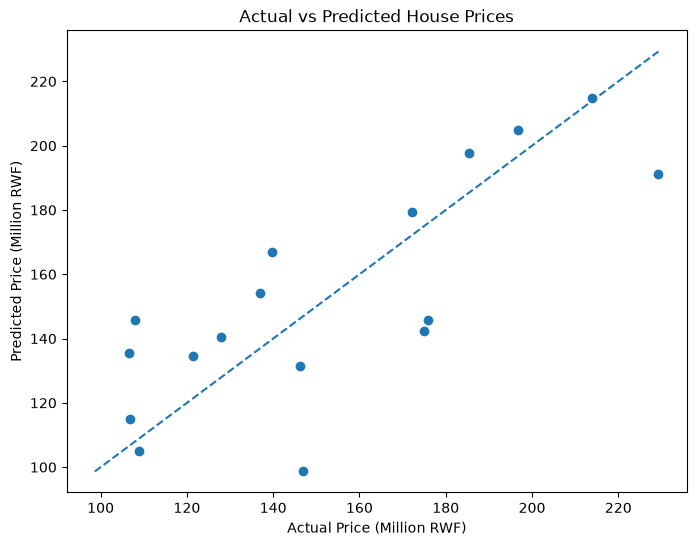

In [39]:
#Actual vs Predicted plot
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred
)

minimum = min(
    y_test.min(),
    y_test_pred.min()
)

maximum = max(
    y_test.max(),
    y_test_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Price (Million RWF)")
plt.ylabel("Predicted Price (Million RWF)")
plt.title("Actual vs Predicted House Prices")

plt.show()

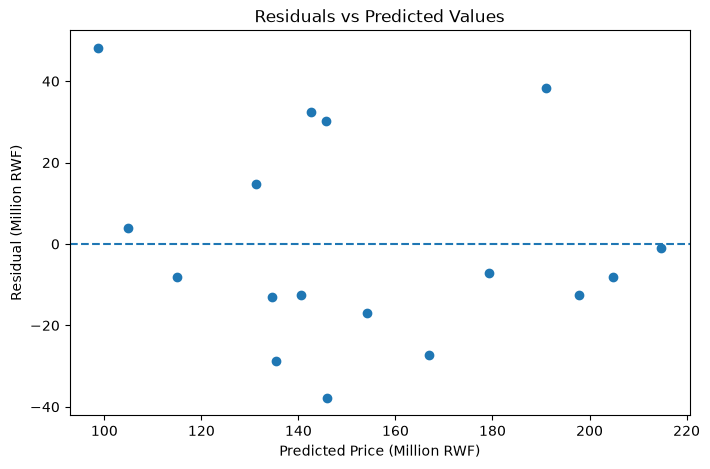

In [40]:
#Residuals vs Predicted
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_pred,
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Price (Million RWF)")
plt.ylabel("Residual (Million RWF)")
plt.title("Residuals vs Predicted Values")

plt.show()

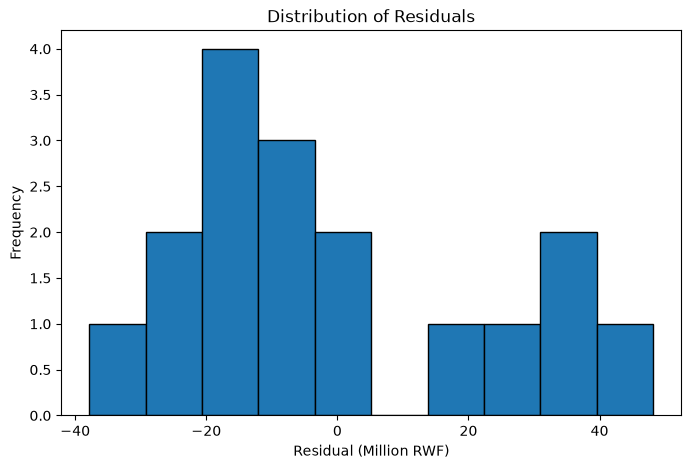

In [41]:
#Residual histogram
plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=10,
    edgecolor="black"
)

plt.xlabel("Residual (Million RWF)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

In [42]:
#Interpret coefficients
coefficient_table
for variable, coefficient in zip(
    feature_names,
    coefficients
):
    print(
        f"{variable}: {coefficient:.4f} million RWF"
    )

num__Area_m2: 1.7199 million RWF
num__Bedrooms: -0.0009 million RWF
num__Bathrooms: -0.3156 million RWF
num__House_Age_Years: 0.1586 million RWF
num__Distance_to_City_km: -0.0053 million RWF
num__Parking_Spaces: 0.0461 million RWF


In [43]:
#Save the model
joblib.dump(
    model,
    "house_price_model.sav"
)

print("Model saved successfully!")

Model saved successfully!


In [44]:
#Load the model again
loaded_model = joblib.load(
    "house_price_model.sav"
)

print("Model loaded successfully!")

Model loaded successfully!


In [45]:
#Confirm predictions are identical
original_predictions = model.predict(X_test)

loaded_predictions = loaded_model.predict(X_test)

print(
    "Same predictions:",
    np.allclose(
        original_predictions,
        loaded_predictions
    )
)

Same predictions: True


In [46]:
#Predict a new house
new_house = pd.DataFrame([{
    "Area_m2": 150,
    "Bedrooms": 3,
    "Bathrooms": 2,
    "House_Age_Years": 5,
    "Distance_to_City_km": 4,
    "Parking_Spaces": 1,
    "Neighborhood": "Gasabo"
}])

new_prediction = loaded_model.predict(
    new_house
)

print(
    f"Predicted house price: "
    f"{new_prediction[0]:.2f} million RWF"
)

Predicted house price: 161.13 million RWF
